## Install dependencies (run once, then restart kernel)

In [1]:
import sys
!{sys.executable} -m pip install numpy nibabel matplotlib scipy tqdm pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ------------- -------------------------- 12.3/36.5 MB 61.3 MB/s eta 0:00:01
   --------------------------- ------------ 24.9/36.5 MB 62.0 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 63.1 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 58.9 MB/s  0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------  9.7/9.7 MB 49.3 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 46.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   -----------------------------------

## Imports and folder setup

In [2]:
import os
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Conference-paper global settings ─────────────────────────────────────────
FONT_SIZE  = 20
DPI        = 600
OUTPUT_DIR = "conference_figures_preprocessing"
os.makedirs(OUTPUT_DIR, exist_ok=True)

matplotlib.rcParams.update({
    'font.size':        FONT_SIZE,
    'axes.labelsize':   FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize':  FONT_SIZE,
    'ytick.labelsize':  FONT_SIZE,
    'font.weight':      'bold',
    'axes.titlesize':   FONT_SIZE,
    'axes.titleweight': 'bold',
})

def make_bold_ticks(ax):
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
        lbl.set_fontsize(FONT_SIZE)

def save_fig(fig, fname):
    path = os.path.join(OUTPUT_DIR, fname)
    fig.savefig(path, dpi=DPI, bbox_inches='tight')
    print(f"Saved → {path}")

# ── Dataset paths ─────────────────────────────────────────────────────────────
dataset_path      = "Task10_Colon"   # <-- change if needed
imagesTr          = os.path.join(dataset_path, "imagesTr")
labelsTr          = os.path.join(dataset_path, "labelsTr")

preprocessed_path = "preprocessed"
os.makedirs(os.path.join(preprocessed_path, "imagesTr"), exist_ok=True)
os.makedirs(os.path.join(preprocessed_path, "labelsTr"), exist_ok=True)

train_images = sorted([f for f in os.listdir(imagesTr) if f.endswith('.nii.gz') and not f.startswith('.')])
train_labels = sorted([f for f in os.listdir(labelsTr) if f.endswith('.nii.gz') and not f.startswith('.')])

print(f"Training images : {len(train_images)}")
print(f"Training labels : {len(train_labels)}")
print(f"Output figures  : {os.path.abspath(OUTPUT_DIR)}")
print(f"DPI={DPI}  FontSize={FONT_SIZE}")

Training images : 126
Training labels : 126
Output figures  : C:\Users\DYPIU\Downloads\COLON\conference_figures_preprocessing
DPI=600  FontSize=20


## Define resampling function

In [3]:
def resample_volume(volume, original_spacing, target_spacing=(1.0, 1.0, 1.0), is_label=False):
    """
    Resample volume to target spacing.
    is_label=True → nearest-neighbour to preserve binary mask.
    """
    zoom_factors = np.array(original_spacing) / np.array(target_spacing)
    order        = 0 if is_label else 1
    return zoom(volume, zoom_factors, order=order)

# Quick test
test_img     = nib.load(os.path.join(imagesTr, train_images[0]))
test_data    = test_img.get_fdata()
test_spacing = test_img.header.get_zooms()

print(f"Original shape   : {test_data.shape}")
print(f"Original spacing : {test_spacing}")
resampled = resample_volume(test_data, test_spacing)
print(f"Resampled shape  : {resampled.shape}")
print(f"Target spacing   : (1.0, 1.0, 1.0)")

Original shape   : (512, 512, 60)
Original spacing : (np.float32(0.779297), np.float32(0.779297), np.float32(7.5))
Resampled shape  : (399, 399, 450)
Target spacing   : (1.0, 1.0, 1.0)


## Define clipping and normalisation functions

In [4]:
def clip_hu(volume, min_hu=-100, max_hu=400):
    """Clip HU values to soft-tissue range (tumour HU mean≈80)."""
    return np.clip(volume, min_hu, max_hu)

def normalize_volume(volume):
    """Z-score normalisation computed on non-background voxels."""
    mask       = volume > volume.min()
    mean       = volume[mask].mean()
    std        = volume[mask].std()
    return (volume - mean) / (std + 1e-8)

clipped    = clip_hu(test_data)
normalized = normalize_volume(clipped)
print(f"After clipping    — Min:{clipped.min():.1f}  Max:{clipped.max():.1f}")
print(f"After normalising — Min:{normalized.min():.3f}  Max:{normalized.max():.3f}  "
      f"Mean:{normalized.mean():.3f}  Std:{normalized.std():.3f}")

After clipping    — Min:-100.0  Max:400.0
After normalising — Min:-1.190  Max:3.145  Mean:-0.777  Std:0.817


## Define complete preprocessing pipeline

In [5]:
def preprocess_case(image_path, label_path, target_spacing=(1.0, 1.0, 1.0)):
    img_nib          = nib.load(image_path)
    lbl_nib          = nib.load(label_path)
    img_data         = img_nib.get_fdata()
    lbl_data         = lbl_nib.get_fdata()
    original_spacing = img_nib.header.get_zooms()

    img_resampled = resample_volume(img_data, original_spacing, target_spacing, is_label=False)
    lbl_resampled = resample_volume(lbl_data, original_spacing, target_spacing, is_label=True)
    img_clipped   = clip_hu(img_resampled)
    img_normalized= normalize_volume(img_clipped)

    stats = {
        'original_shape'   : img_data.shape,
        'resampled_shape'  : img_resampled.shape,
        'original_spacing' : original_spacing,
        'target_spacing'   : target_spacing,
        'tumor_voxels_orig': int(np.sum(lbl_data == 1)),
        'tumor_voxels_new' : int(np.sum(lbl_resampled == 1)),
    }
    return img_normalized, lbl_resampled, stats

# Test on first case
img_out, lbl_out, stats = preprocess_case(
    os.path.join(imagesTr, train_images[0]),
    os.path.join(labelsTr, train_labels[0])
)
print("=== PREPROCESSING TEST ===")
for k, v in stats.items():
    print(f"   {k:25s}: {v}")
print(f"Output image : {img_out.shape}  |  label : {lbl_out.shape}")
print(f"Unique labels: {np.unique(lbl_out)}")

=== PREPROCESSING TEST ===
   original_shape           : (512, 512, 60)
   resampled_shape          : (399, 399, 450)
   original_spacing         : (np.float32(0.779297), np.float32(0.779297), np.float32(7.5))
   target_spacing           : (1.0, 1.0, 1.0)
   tumor_voxels_orig        : 1783
   tumor_voxels_new         : 8115
Output image : (399, 399, 450)  |  label : (399, 399, 450)
Unique labels: [0. 1.]


## Fig 1 – Before vs after preprocessing (6-panel)

Saved → conference_figures_preprocessing\fig1_preprocessing_comparison.png


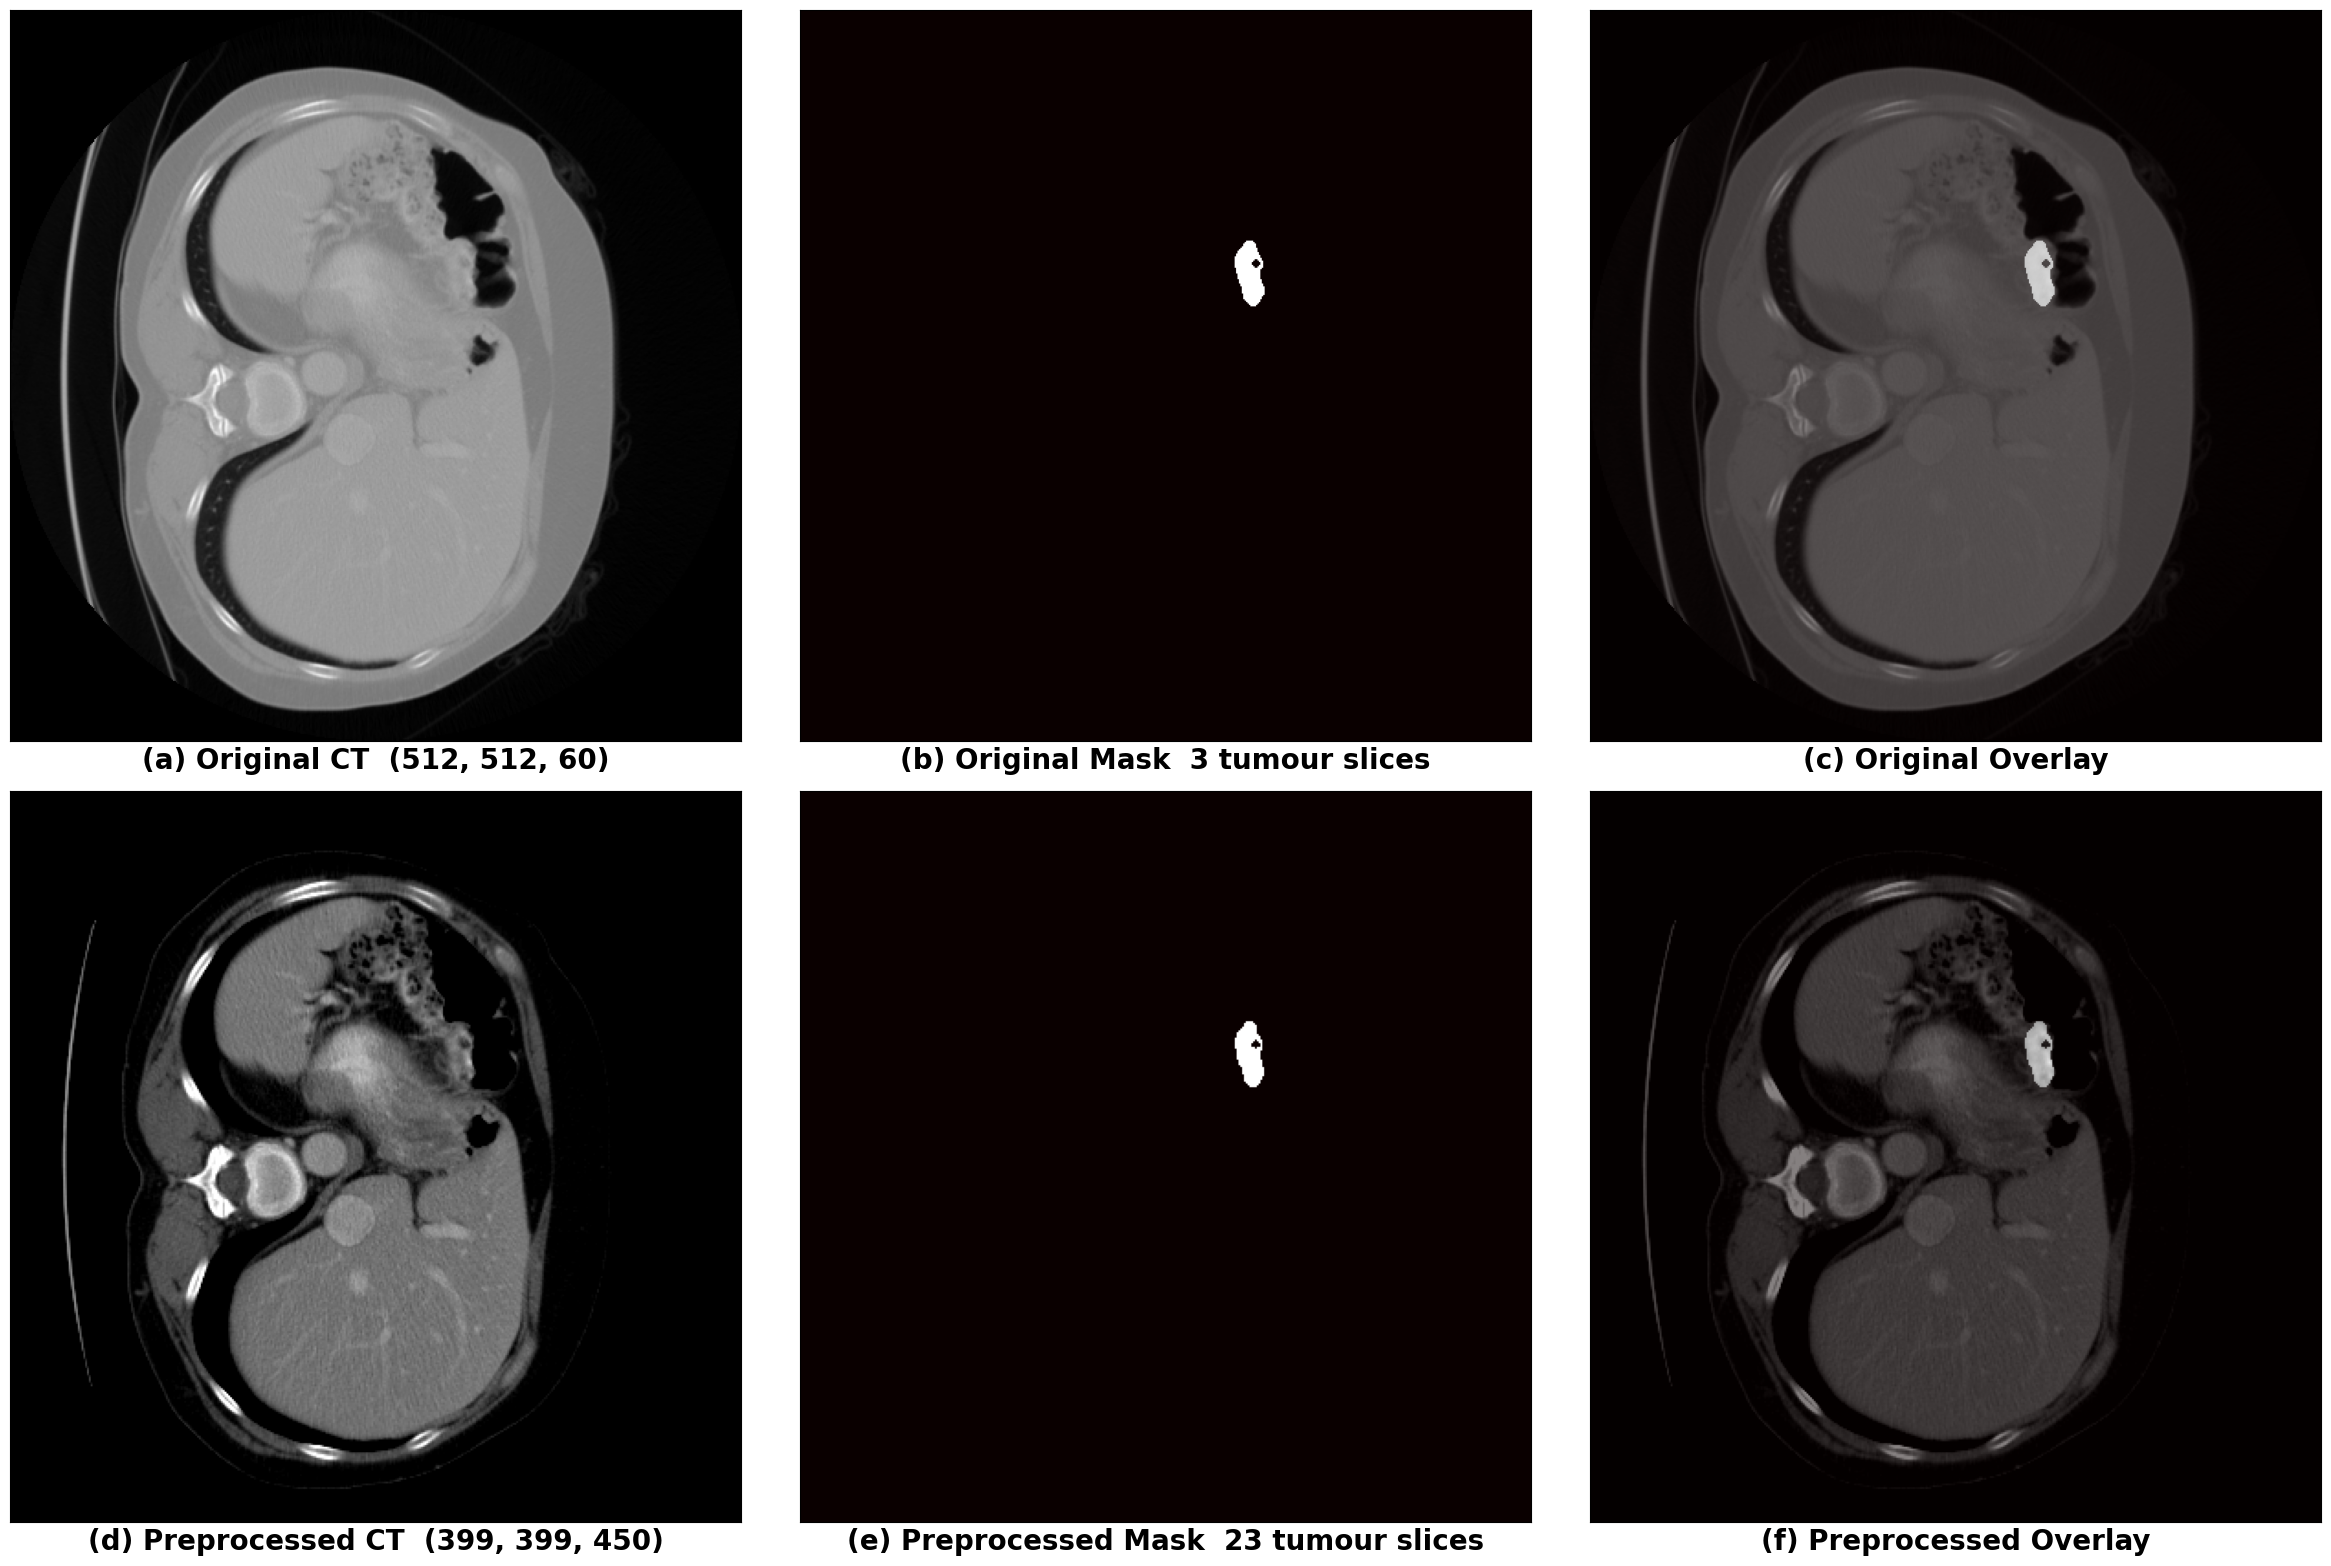

In [6]:
img_orig = nib.load(os.path.join(imagesTr, train_images[0])).get_fdata()
lbl_orig = nib.load(os.path.join(labelsTr, train_labels[0])).get_fdata()

orig_tumor_slices = [i for i in range(lbl_orig.shape[2]) if np.any(lbl_orig[:,:,i] == 1)]
new_tumor_slices  = [i for i in range(lbl_out.shape[2])  if np.any(lbl_out[:,:,i]  == 1)]
orig_mid = orig_tumor_slices[len(orig_tumor_slices)//2]
new_mid  = new_tumor_slices [len(new_tumor_slices) //2]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# Row 1 — original
axes[0,0].imshow(img_orig[:,:,orig_mid], cmap='gray')
axes[0,0].set_xlabel(f'(a) Original CT  {img_orig.shape}', fontweight='bold', fontsize=FONT_SIZE)
axes[0,0].set_xticks([]); axes[0,0].set_yticks([])

axes[0,1].imshow(lbl_orig[:,:,orig_mid], cmap='hot')
axes[0,1].set_xlabel(f'(b) Original Mask  {len(orig_tumor_slices)} tumour slices',
                     fontweight='bold', fontsize=FONT_SIZE)
axes[0,1].set_xticks([]); axes[0,1].set_yticks([])

axes[0,2].imshow(img_orig[:,:,orig_mid], cmap='gray')
axes[0,2].imshow(lbl_orig[:,:,orig_mid], cmap='hot', alpha=0.5)
axes[0,2].set_xlabel('(c) Original Overlay', fontweight='bold', fontsize=FONT_SIZE)
axes[0,2].set_xticks([]); axes[0,2].set_yticks([])

# Row 2 — preprocessed
axes[1,0].imshow(img_out[:,:,new_mid], cmap='gray')
axes[1,0].set_xlabel(f'(d) Preprocessed CT  {img_out.shape}', fontweight='bold', fontsize=FONT_SIZE)
axes[1,0].set_xticks([]); axes[1,0].set_yticks([])

axes[1,1].imshow(lbl_out[:,:,new_mid], cmap='hot')
axes[1,1].set_xlabel(f'(e) Preprocessed Mask  {len(new_tumor_slices)} tumour slices',
                     fontweight='bold', fontsize=FONT_SIZE)
axes[1,1].set_xticks([]); axes[1,1].set_yticks([])

axes[1,2].imshow(img_out[:,:,new_mid], cmap='gray')
axes[1,2].imshow(lbl_out[:,:,new_mid], cmap='hot', alpha=0.5)
axes[1,2].set_xlabel('(f) Preprocessed Overlay', fontweight='bold', fontsize=FONT_SIZE)
axes[1,2].set_xticks([]); axes[1,2].set_yticks([])

fig.tight_layout()
save_fig(fig, 'fig1_preprocessing_comparison.png')
plt.show()

## Fig 2 – HU intensity: raw vs clipped vs normalised (3-panel)

Saved → conference_figures_preprocessing\fig2_hu_intensity_pipeline.png


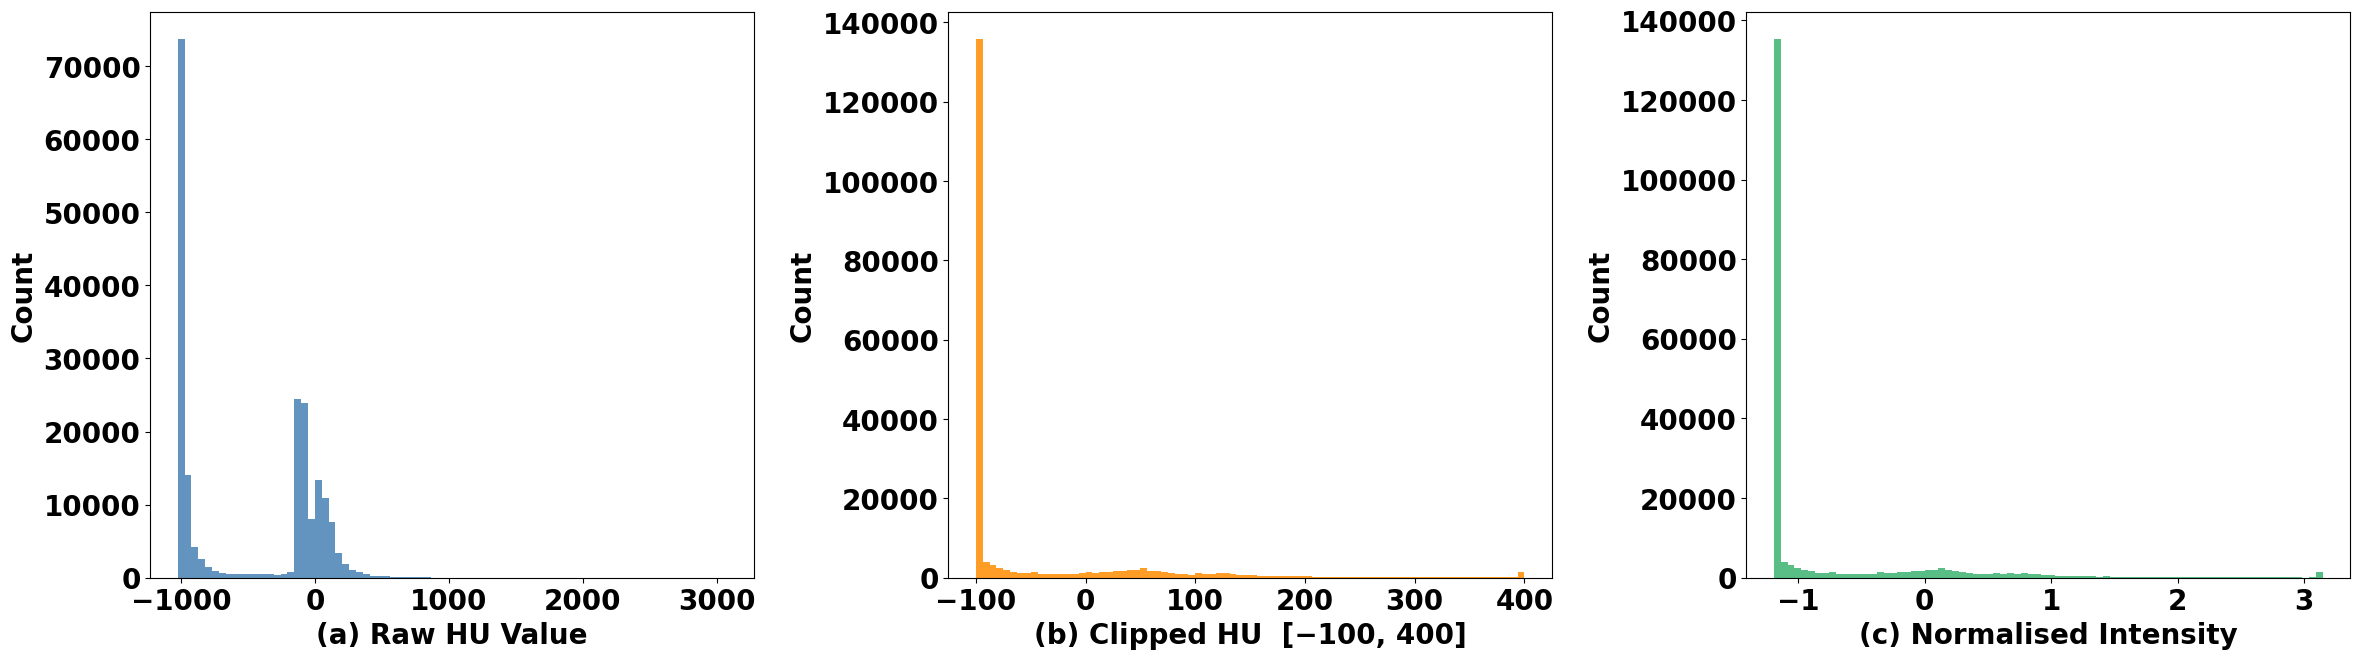

In [7]:
raw_vals    = img_orig.flatten()
clipped_vals= clip_hu(img_orig).flatten()
norm_vals   = normalize_volume(clip_hu(img_orig)).flatten()

# Sample to keep memory manageable
rng     = np.random.default_rng(42)
n_samp  = 200_000
raw_s   = rng.choice(raw_vals,    size=n_samp, replace=False)
clip_s  = rng.choice(clipped_vals,size=n_samp, replace=False)
norm_s  = rng.choice(norm_vals,   size=n_samp, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

axes[0].hist(raw_s,  bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_xlabel('(a) Raw HU Value',      fontweight='bold', fontsize=FONT_SIZE)
axes[0].set_ylabel('Count',                 fontweight='bold', fontsize=FONT_SIZE)
make_bold_ticks(axes[0])

axes[1].hist(clip_s, bins=80, color='darkorange', edgecolor='none', alpha=0.85)
axes[1].set_xlabel('(b) Clipped HU  [−100, 400]', fontweight='bold', fontsize=FONT_SIZE)
axes[1].set_ylabel('Count',                        fontweight='bold', fontsize=FONT_SIZE)
make_bold_ticks(axes[1])

axes[2].hist(norm_s, bins=80, color='mediumseagreen', edgecolor='none', alpha=0.85)
axes[2].set_xlabel('(c) Normalised Intensity', fontweight='bold', fontsize=FONT_SIZE)
axes[2].set_ylabel('Count',                    fontweight='bold', fontsize=FONT_SIZE)
make_bold_ticks(axes[2])

fig.tight_layout()
save_fig(fig, 'fig2_hu_intensity_pipeline.png')
plt.show()

## Preprocess and save all cases

In [8]:
import time

save_dir_imgs = os.path.join(preprocessed_path, "imagesTr")
save_dir_lbls = os.path.join(preprocessed_path, "labelsTr")

all_stats = []
failed    = []
start     = time.time()

for fname_img, fname_lbl in tqdm(zip(train_images, train_labels), total=len(train_images)):
    try:
        img_out, lbl_out, stats = preprocess_case(
            os.path.join(imagesTr, fname_img),
            os.path.join(labelsTr, fname_lbl)
        )
        nib.save(nib.Nifti1Image(img_out.astype(np.float32), affine=np.eye(4)),
                 os.path.join(save_dir_imgs, fname_img))
        nib.save(nib.Nifti1Image(lbl_out.astype(np.uint8),   affine=np.eye(4)),
                 os.path.join(save_dir_lbls, fname_lbl))
        stats['filename'] = fname_img
        all_stats.append(stats)
    except Exception as e:
        print(f"Failed: {fname_img} — {e}")
        failed.append(fname_img)

elapsed = time.time() - start
print(f"Done!  {len(all_stats)}/{len(train_images)} cases processed")
print(f"Failed: {len(failed)}")
print(f"Time  : {elapsed/60:.1f} min")

100%|████████████████████████████████████████████████████████████████████████████████| 126/126 [34:50<00:00, 16.59s/it]

Done!  126/126 cases processed
Failed: 0
Time  : 34.8 min


## Verify saved files and summarise stats

In [9]:
import pandas as pd

saved_imgs = sorted([f for f in os.listdir(save_dir_imgs) if f.endswith('.nii.gz')])
saved_lbls = sorted([f for f in os.listdir(save_dir_lbls) if f.endswith('.nii.gz')])
print(f"Saved images: {len(saved_imgs)}  |  Saved labels: {len(saved_lbls)}")

df               = pd.DataFrame(all_stats)
resampled_shapes = np.array([s['resampled_shape'] for s in all_stats])
tumor_new        = np.array([s['tumor_voxels_new']  for s in all_stats])
tumor_orig       = np.array([s['tumor_voxels_orig'] for s in all_stats])

print(f"\n=== SHAPE STATS AFTER PREPROCESSING ===")
print(f"Min shape : {resampled_shapes.min(axis=0)}")
print(f"Max shape : {resampled_shapes.max(axis=0)}")
print(f"Mean shape: {resampled_shapes.mean(axis=0).astype(int)}")

print(f"\n=== TUMOR VOXEL STATS ===")
print(f"Min / Max / Mean (orig) : {tumor_orig.min()} / {tumor_orig.max()} / {tumor_orig.mean():.0f}")
print(f"Min / Max / Mean (new)  : {tumor_new.min()}  / {tumor_new.max()}  / {tumor_new.mean():.0f}")
print(f"Mean increase           : {(tumor_new/tumor_orig).mean():.1f}x")

Saved images: 126  |  Saved labels: 126

=== SHAPE STATS AFTER PREPROCESSING ===
Min shape : [274 274 185]
Max shape : [500 500 911]
Mean shape: [400 400 446]

=== TUMOR VOXEL STATS ===
Min / Max / Mean (orig) : 359 / 148106 / 14353
Min / Max / Mean (new)  : 1165  / 471903  / 36322
Mean increase           : 2.9x


## Fig 3 – Shape change: original vs resampled (3-panel)

Saved → conference_figures_preprocessing\fig3_shape_change.png


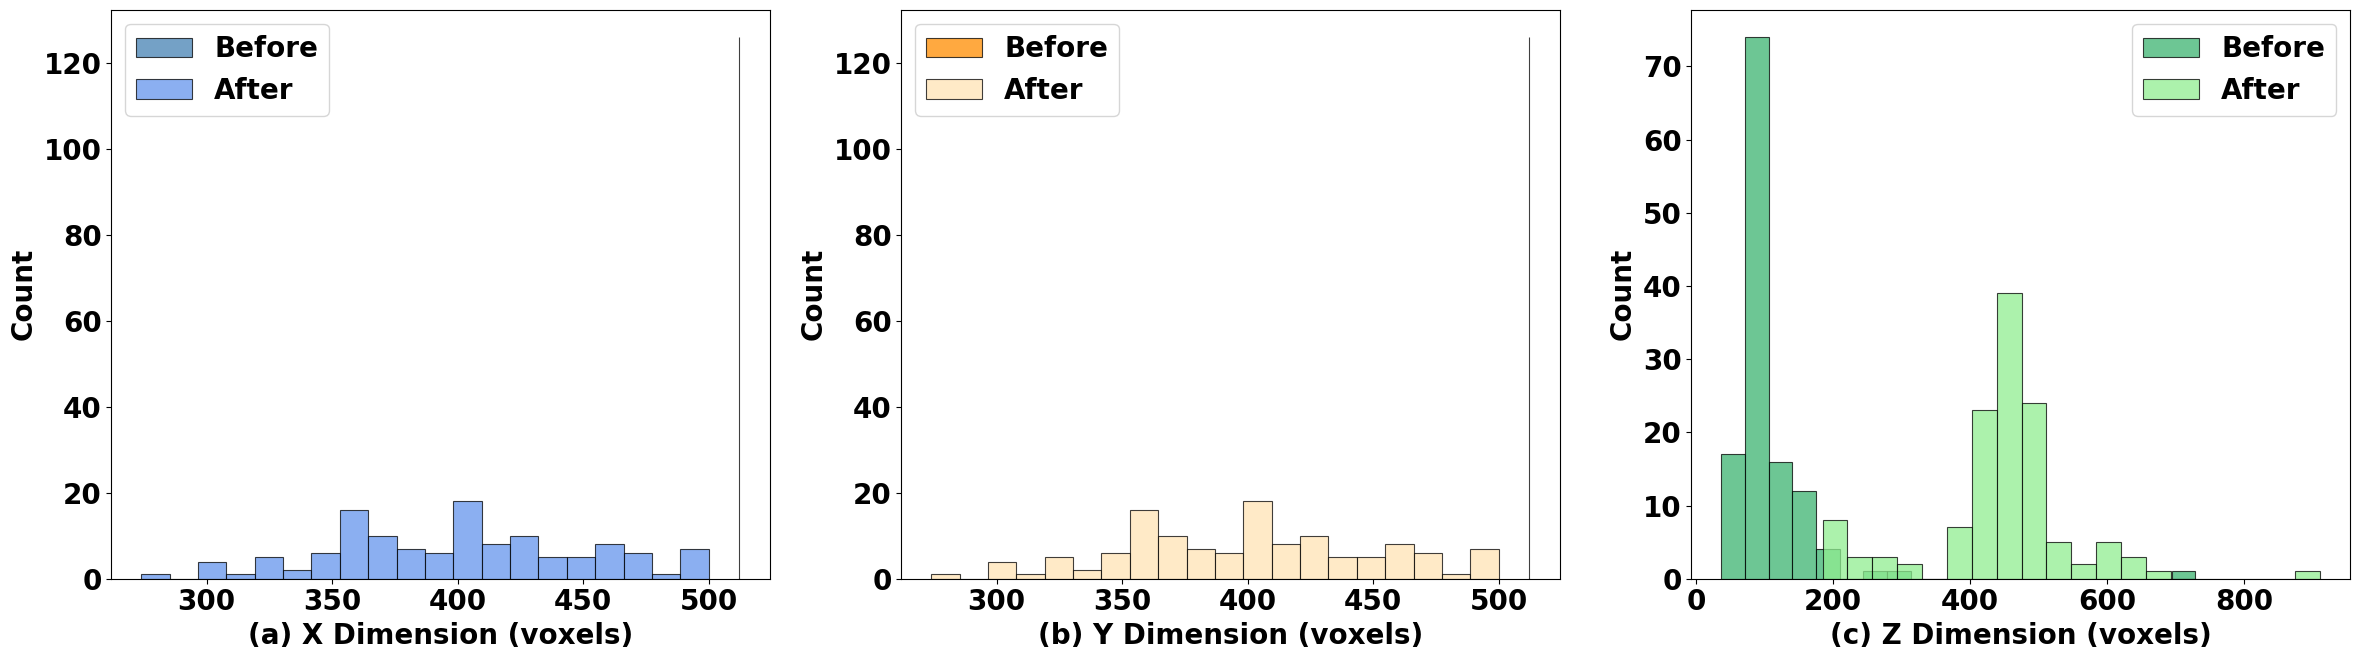

In [10]:
orig_shapes = np.array([s['original_shape']  for s in all_stats])
new_shapes  = np.array([s['resampled_shape'] for s in all_stats])

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
dims   = ['X', 'Y', 'Z']
colors = [('steelblue','cornflowerblue'),
          ('darkorange','moccasin'),
          ('mediumseagreen','lightgreen')]

for d in range(3):
    axes[d].hist(orig_shapes[:,d], bins=20, color=colors[d][0], alpha=0.75,
                 edgecolor='black', linewidth=0.8, label='Before')
    axes[d].hist(new_shapes[:,d],  bins=20, color=colors[d][1], alpha=0.75,
                 edgecolor='black', linewidth=0.8, label='After')
    axes[d].set_xlabel(f'({chr(97+d)}) {dims[d]} Dimension (voxels)',
                       fontweight='bold', fontsize=FONT_SIZE)
    axes[d].set_ylabel('Count', fontweight='bold', fontsize=FONT_SIZE)
    leg = axes[d].legend(fontsize=FONT_SIZE)
    for t in leg.get_texts():
        t.set_fontweight('bold')
    make_bold_ticks(axes[d])

fig.tight_layout()
save_fig(fig, 'fig3_shape_change.png')
plt.show()

## Fig 4 – Tumour voxel count: before vs after resampling (2-panel)

Saved → conference_figures_preprocessing\fig4_tumor_voxel_change.png


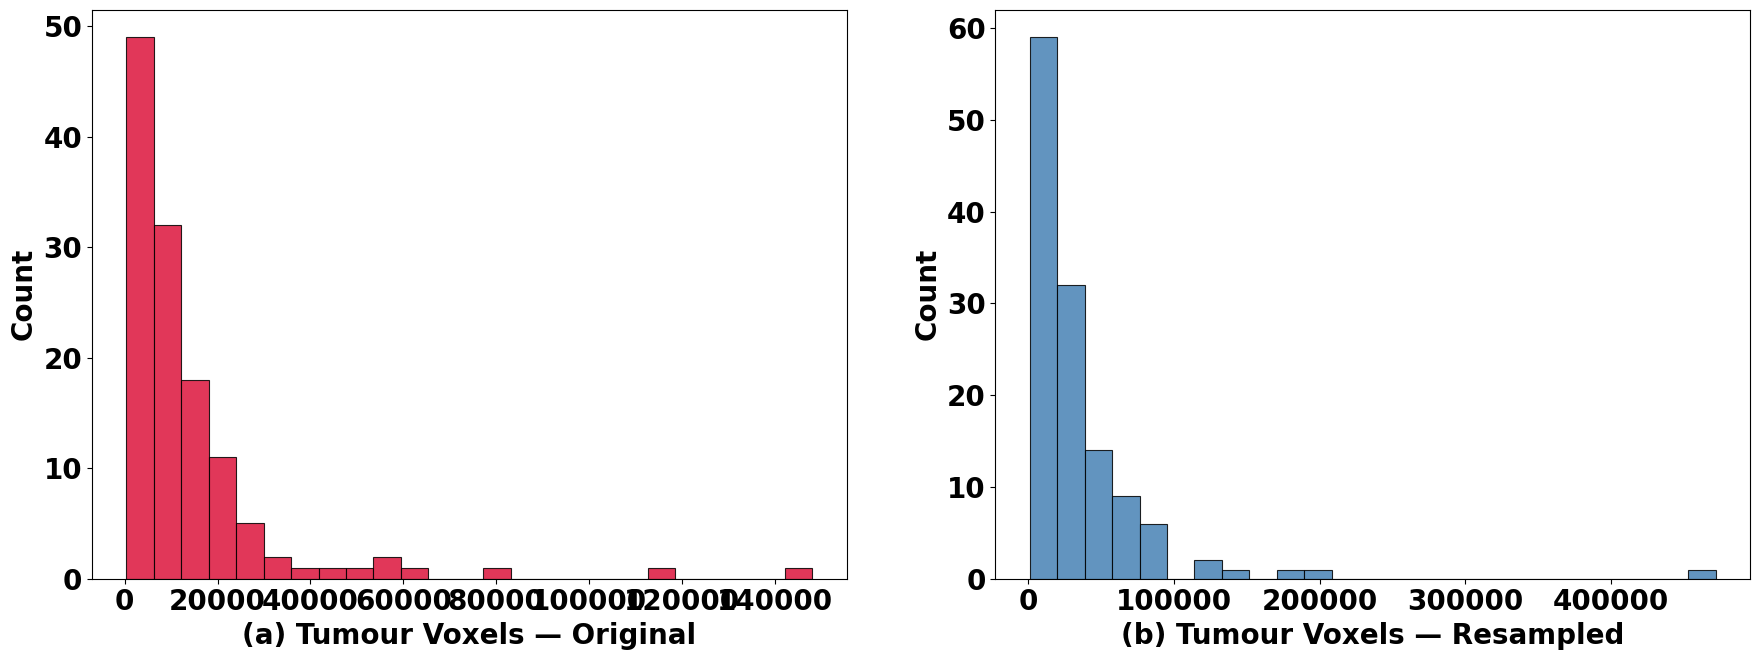

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].hist(tumor_orig, bins=25, color='crimson', edgecolor='black', linewidth=0.8, alpha=0.85)
axes[0].set_xlabel('(a) Tumour Voxels — Original', fontweight='bold', fontsize=FONT_SIZE)
axes[0].set_ylabel('Count',                        fontweight='bold', fontsize=FONT_SIZE)
make_bold_ticks(axes[0])

axes[1].hist(tumor_new,  bins=25, color='steelblue', edgecolor='black', linewidth=0.8, alpha=0.85)
axes[1].set_xlabel('(b) Tumour Voxels — Resampled', fontweight='bold', fontsize=FONT_SIZE)
axes[1].set_ylabel('Count',                         fontweight='bold', fontsize=FONT_SIZE)
make_bold_ticks(axes[1])

fig.tight_layout()
save_fig(fig, 'fig4_tumor_voxel_change.png')
plt.show()

## Fig 5 – Preprocessed cases verification (9-panel)

Saved → conference_figures_preprocessing\fig5_preprocessed_verification.png


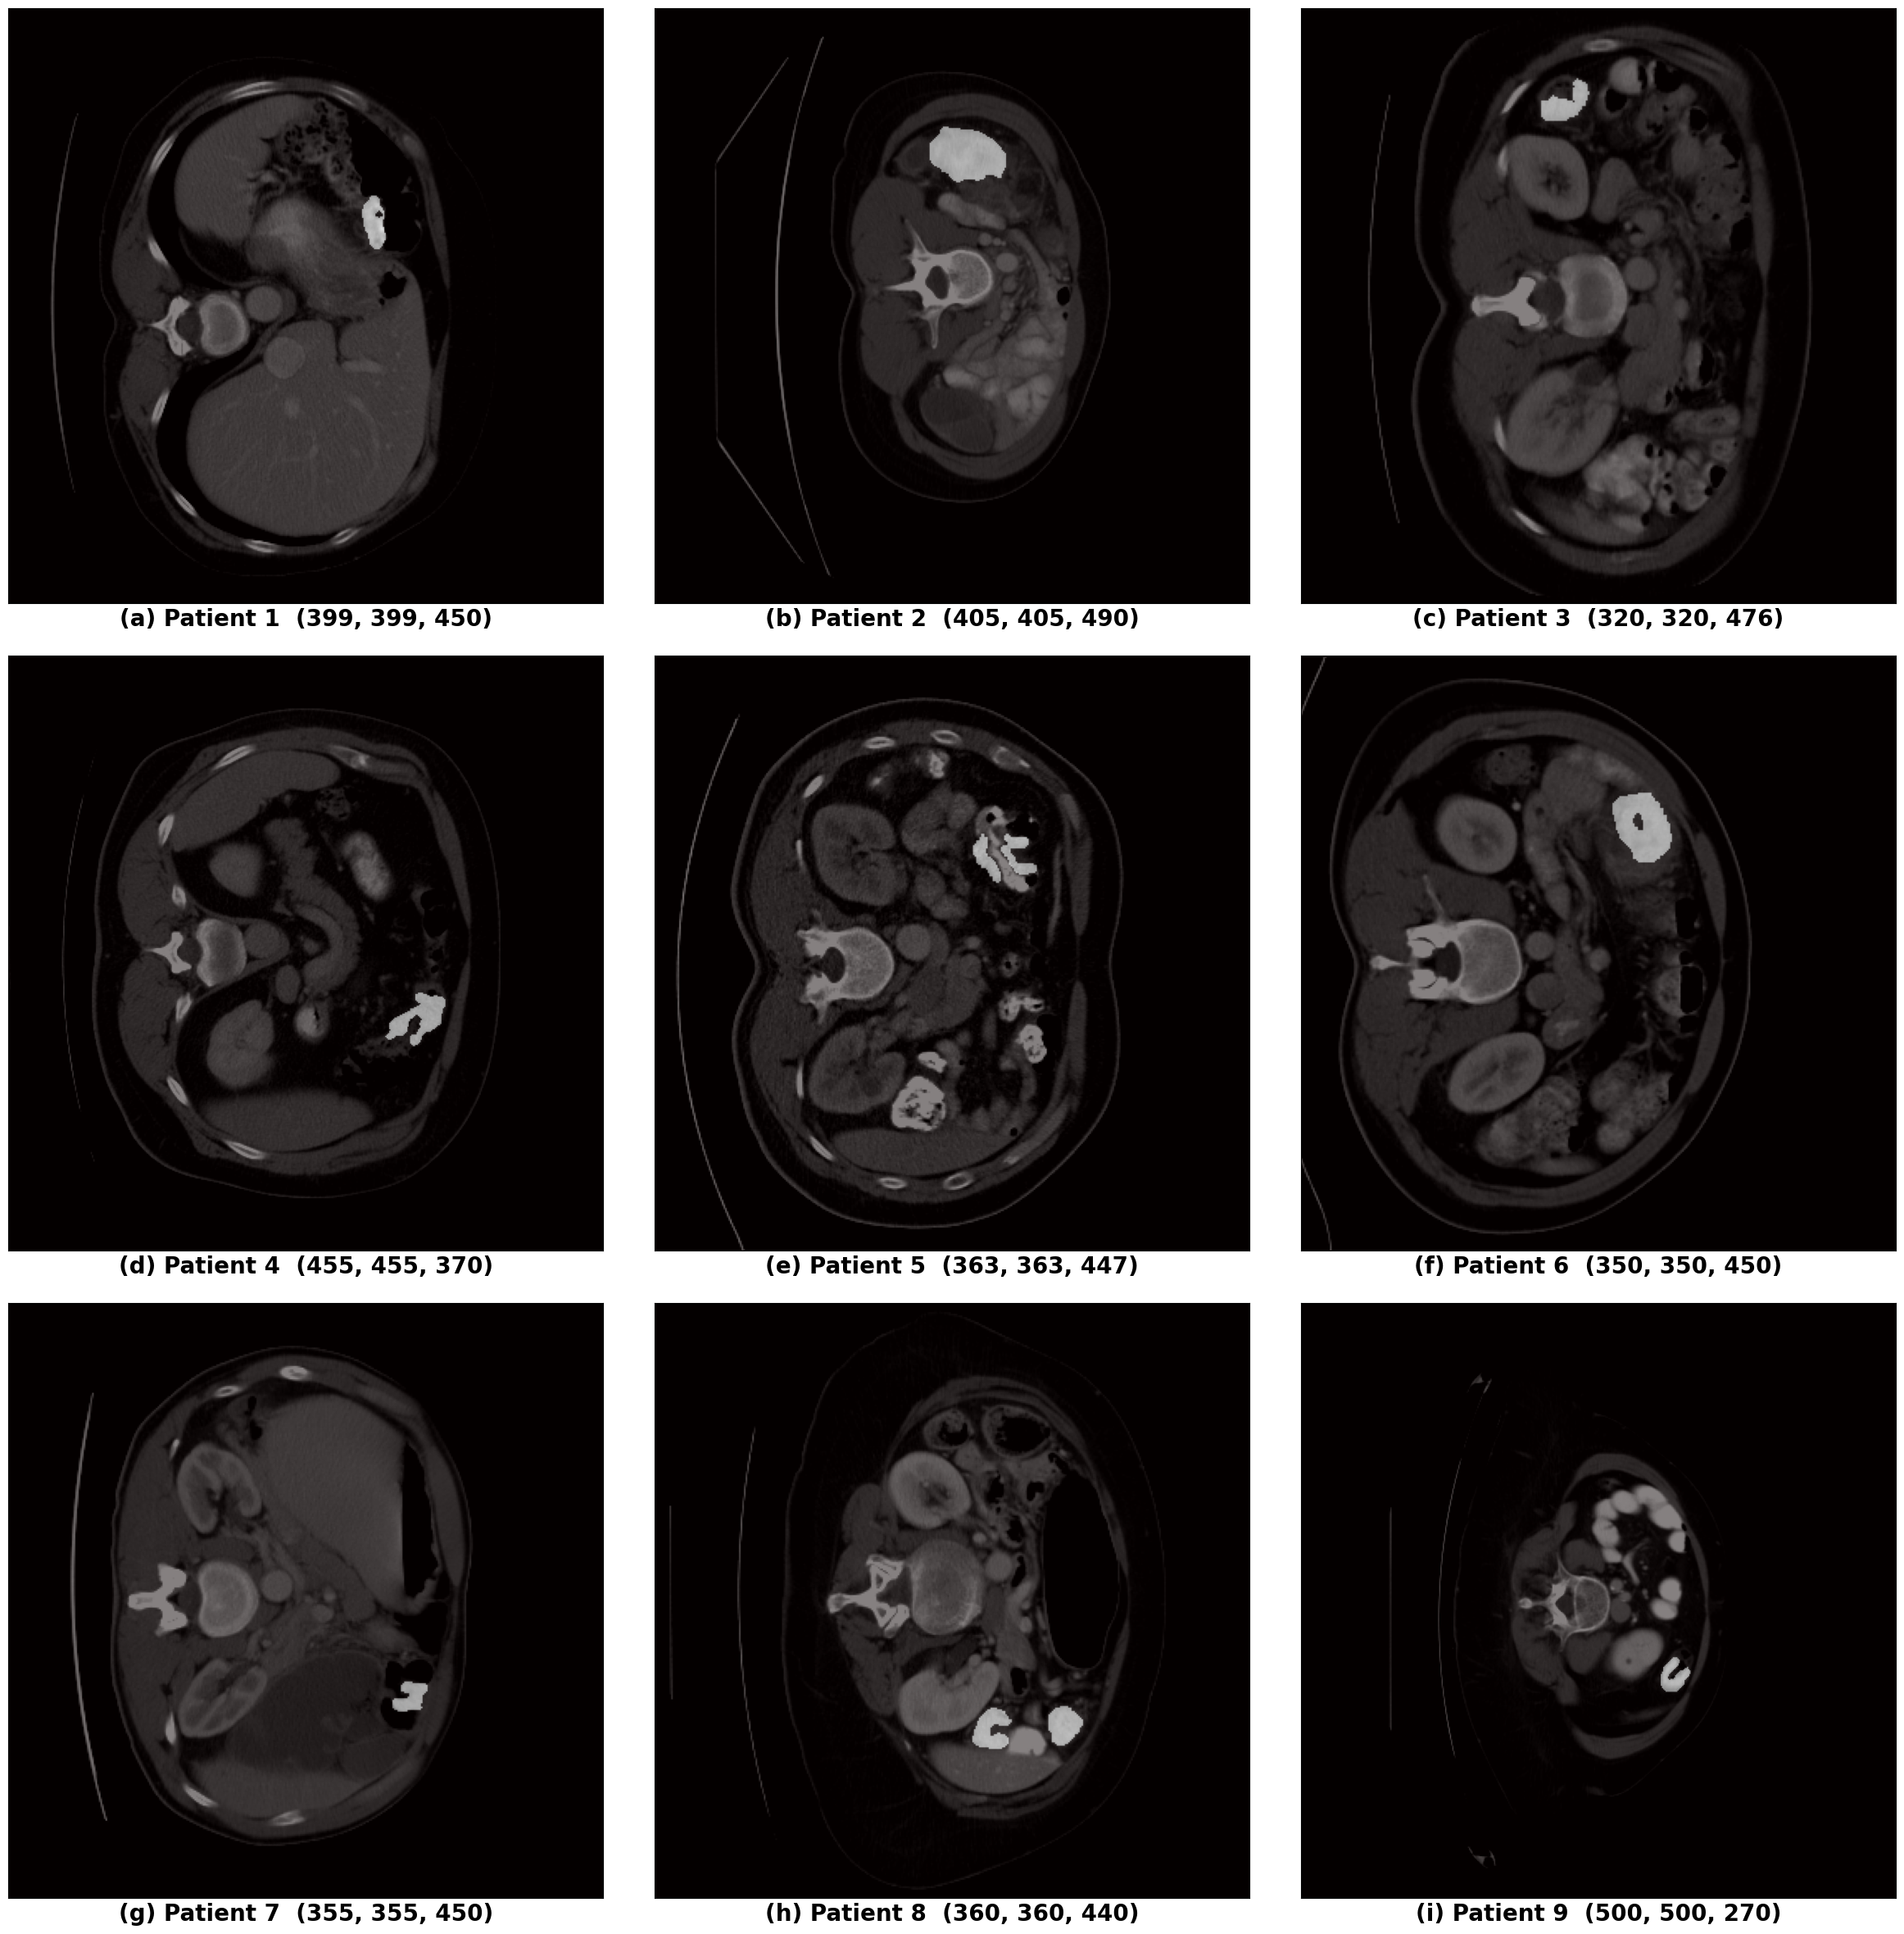

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(24, 24))
axes      = axes.flatten()
abc       = list('abcdefghi')

for idx in range(9):
    img_data     = nib.load(os.path.join(save_dir_imgs, saved_imgs[idx])).get_fdata()
    lbl_data     = nib.load(os.path.join(save_dir_lbls, saved_lbls[idx])).get_fdata()
    tumor_slices = [i for i in range(lbl_data.shape[2]) if np.any(lbl_data[:,:,i] == 1)]
    mid_slice    = tumor_slices[len(tumor_slices)//2]

    axes[idx].imshow(img_data[:,:,mid_slice], cmap='gray')
    axes[idx].imshow(lbl_data[:,:,mid_slice], cmap='hot', alpha=0.5)
    axes[idx].set_xlabel(
        f'({abc[idx]}) Patient {idx+1}  {img_data.shape}',
        fontweight='bold', fontsize=FONT_SIZE)
    axes[idx].set_xticks([]); axes[idx].set_yticks([])

fig.tight_layout()
save_fig(fig, 'fig5_preprocessed_verification.png')
plt.show()

## Final preprocessing summary

In [13]:
print("=" * 60)
print("PREPROCESSING NOTEBOOK — COMPLETE SUMMARY")
print("=" * 60)

print(f"\n STEPS COMPLETED")
print(f"   1. Resampled to isotropic 1.0x1.0x1.0 mm spacing")
print(f"   2. Clipped HU to [-100, 400]")
print(f"   3. Z-score normalised (mean=0, std=1)")
print(f"   4. Saved {len(all_stats)} cases as .nii.gz")

print(f"\n OUTPUT LOCATIONS")
print(f"   Images   : {os.path.abspath(save_dir_imgs)}")
print(f"   Labels   : {os.path.abspath(save_dir_lbls)}")
print(f"   Figures  : {os.path.abspath(OUTPUT_DIR)}/")

print(f"\n SHAPE CHANGES")
print(f"   Before : {orig_shapes.min(axis=0)} → {orig_shapes.max(axis=0)}")
print(f"   After  : {new_shapes.min(axis=0)}  → {new_shapes.max(axis=0)}")

print(f"\n TUMOR VOXEL CHANGES")
print(f"   Before : min={tumor_orig.min()}  max={tumor_orig.max()}  mean={tumor_orig.mean():.0f}")
print(f"   After  : min={tumor_new.min()}   max={tumor_new.max()}   mean={tumor_new.mean():.0f}")
print(f"   Increase: ~{(tumor_new/tumor_orig).mean():.1f}x  (isotropic resampling expands z)")

print(f"\n FIGURES SAVED")
for fn in ['fig1_preprocessing_comparison.png',
           'fig2_hu_intensity_pipeline.png',
           'fig3_shape_change.png',
           'fig4_tumor_voxel_change.png',
           'fig5_preprocessed_verification.png']:
    print(f"   {fn}")
print("=" * 60)

PREPROCESSING NOTEBOOK — COMPLETE SUMMARY

 STEPS COMPLETED
   1. Resampled to isotropic 1.0x1.0x1.0 mm spacing
   2. Clipped HU to [-100, 400]
   3. Z-score normalised (mean=0, std=1)
   4. Saved 126 cases as .nii.gz

 OUTPUT LOCATIONS
   Images   : C:\Users\DYPIU\Downloads\COLON\preprocessed\imagesTr
   Labels   : C:\Users\DYPIU\Downloads\COLON\preprocessed\labelsTr
   Figures  : C:\Users\DYPIU\Downloads\COLON\conference_figures_preprocessing/

 SHAPE CHANGES
   Before : [512 512  37] → [512 512 729]
   After  : [274 274 185]  → [500 500 911]

 TUMOR VOXEL CHANGES
   Before : min=359  max=148106  mean=14353
   After  : min=1165   max=471903   mean=36322
   Increase: ~2.9x  (isotropic resampling expands z)

 FIGURES SAVED
   fig1_preprocessing_comparison.png
   fig2_hu_intensity_pipeline.png
   fig3_shape_change.png
   fig4_tumor_voxel_change.png
   fig5_preprocessed_verification.png
